#A. Cel projektu

Celem niniejszego sprawozdania jest dogłębna eksploracja i analiza statystyczna zbioru danych motoryzacyjnych carbig. Projekt zakłada oczyszczenie danych (wypełnienie braków najczęściej występującą wartością) oraz przeprowadzenie wielowymiarowej analizy parametrów technicznych pojazdów (takich jak moc, waga czy spalanie). Weryfikacji poddane zostaną miary statystyki opisowej: położenia, rozproszenia i kształtu rozkładu. Ponadto, przy użyciu metod graficznej prezentacji (wykresy pudełkowe, histogramy, macierze rozproszenia), zbadana zostanie siła i kierunek współzależności między poszczególnymi cechami numerycznymi badanych samochodów.


# B. Wstęp teoretyczny:

**1. Miary położenia**
Służą one do określenia centrum rozkładu danych lub tendencji centralnej.

* Średnia arytmetyczna: Wyliczana jako suma wartości podzielona przez ich liczbę, wyrażona wzorem $\overline{x}=\frac{1}{n}\sum_{i=1}^{n}x_{i}$.
* Kwantyle: Są to wartości danej cechy, które dzielą ją na określone części pod względem liczby jednostek, przy czym dane muszą być uporządkowane niemalejąco. Szczególnym przypadkiem są kwartyle.
* Mediana (Kwartyl drugi $Q_{2}$): Dzieli dane tak, że dokładnie połowa jednostek ma wartości niższe lub równe, a druga połowa wyższe lub równe niż kwartyl.
* Moda (Dominanta): To wartość, która pojawia się w zbiorze danych najczęściej.

**2. Miary zmienności (dyspersji)**
Opisują one zróżnicowanie i rozproszenie danych wokół ich środka.

* Rozstęp: Jest to prosta różnica między wartością maksymalną a minimalną w zbiorze: $r=x_{max}-x_{min}$.
* Rozstęp międzykwartylowy (IQR): Liczony jako różnica między kwartylem górnym i dolnym: $Q_{3}-Q_{1}$.
* Wariancja: Wyraża się wzorem $s^{2}=\frac{1}{n}\sum_{i=1}^{n}(x_{i}-\overline{x})^{2}$.
* Odchylenie standardowe: Stanowi pierwiastek z wariancji, czyli $s=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_{i}-\overline{x})^{2}}$.

**3. Kształt rozkładu i badanie współzależności**
Rozkłady empiryczne cech mogą różnić się od idealnego rozkładu normalnego (Gaussowskiego).

* Współczynnik asymetrii (skośność): Służy do opisu miary asymetrii rozkładu. Wylicza się go ze wzoru: $A_{s}=\frac{1}{s^{3}}\cdot(\frac{1}{n}\sum_{i=1}^{n}(x_{i}-\overline{x})^{3})$.
* Kurtoza: Określa stopień spłaszczenia rozkładu i jest zdefiniowana jako: $K=\frac{1}{s^{4}}(\frac{1}{n}\sum_{i=1}^{n}(x_{i}-\overline{x})^{4})$.
* Współczynnik korelacji Pearsona $(r_{xy})$: Pozwala określić siłę i kierunek zależności liniowej między dwiema zmiennymi. Zdefiniowany jest wzorem: $r_{xy}=\frac{cov(x,y)}{s(x)\cdot s(y)}$. Współczynnik ten przyjmuje wartości z przedziału $\langle-1,1\rangle$. Gdy $|r_{xy}|$ jest bliskie 1, mamy do czynienia z silną zależnością liniową. Jeśli $r_{xy}>0$, zależność jest dodatnia, a jeśli $r_{xy}<0$ ujemna.

**4. Wybrane metody graficznej prezentacji danych**

* Wykres pudełkowy (Boxplot): Pokazuje strukturę rozkładu na podstawie mediany i kwartyli. Długość jego "wąsów" jest zwykle równa 1,5 IQR. Obserwacje znajdujące się poza tym obszarem są oznaczane jako obserwacje odstające.
* Histogram: Jest to graficzny sposób przedstawiania rozkładu empirycznego. Pokazuje on liczebności obserwacji w zadanych przedziałach badanej zmiennej.


**Krok 1: Wstępne przetwarzanie i imputacja braków danych**

*Opis kroku: Zastąpienie wartości pustych (NaN) dominantą (mode) oraz wprowadzenie losowego szumu w celu symulacji rzeczywistych anomalii pomiarowych.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('carbig.csv')
np.random.seed(int(5.1 * 2026))
# Replace NaN
columns = ['Acceleration', 'Displacement', 'Horsepower', 'Weight', 'MPG']
for col in columns:
  data[col] = data[col].fillna(data[col].mode()[0])
# Select columns
x = data[columns].values
noise_multiplier = 1 + (np.random.rand(*x.shape) * 2 - 1) / 100
x = x * noise_multiplier
print(data.head(3))

                                  Model   Origin   MPG  Cylinders  \
0  chevrolet chevelle malibu             USA      18.0          8   
1  buick skylark 320                     USA      15.0          8   
2  plymouth satellite                    USA      18.0          8   

   Displacement  Horsepower  Weight  Acceleration  Model_Year  
0         307.0       130.0    3504          12.0          70  
1         350.0       165.0    3693          11.5          70  
2         318.0       150.0    3436          11.0          70  


**Krok 2: Analiza miar tendencji centralnej i rozproszenia**

*Opis kroku: Wyznaczenie wartości minimalnych, maksymalnych oraz miar średnich , a także kwartyli, rozstępu międzykwartylowego i wizualizacja za pomocą wykresów pudełkowych (boxplot).*

In [ ]:
# Obliczamy statystyki
stats = pd.DataFrame({
    'Min': np.min(x, axis=0),
    'Max': np.max(x, axis=0),
    'Średnia': np.mean(x, axis=0)
}, index=columns)
print(stats)


                      Min          Max      Średnia
Acceleration     7.938422    24.720508    15.507619
Displacement    67.448484   458.520406   194.754697
Horsepower      46.134668   230.241897   105.777881
Weight        1603.868804  5187.202074  2979.747606
MPG              8.934786    46.718547    23.317795


                       q1           q3       median      rozstep          iqr  \
Acceleration    13.714148    17.129045    15.443736    16.782086     3.414898   
Displacement   104.552761   300.455867   149.610879   391.071922   195.903106   
Horsepower      76.447385   132.733745    94.683264   184.107230    56.286360   
Weight        2227.058691  3621.229547  2813.285884  3583.333269  1394.170856   
MPG             16.933610    29.065067    22.456095    37.783761    12.131457   

              odchylenie_cw  typ_min, od:  typ_max, do:  
Acceleration       1.707449     13.736288     17.151185  
Displacement      97.951553     51.659326    247.562432  
Horsepower        28.143180     66.540084    122.826444  
Weight           697.085428   2116.200456   3510.371312  
MPG                6.065729     16.390367     28.521824  


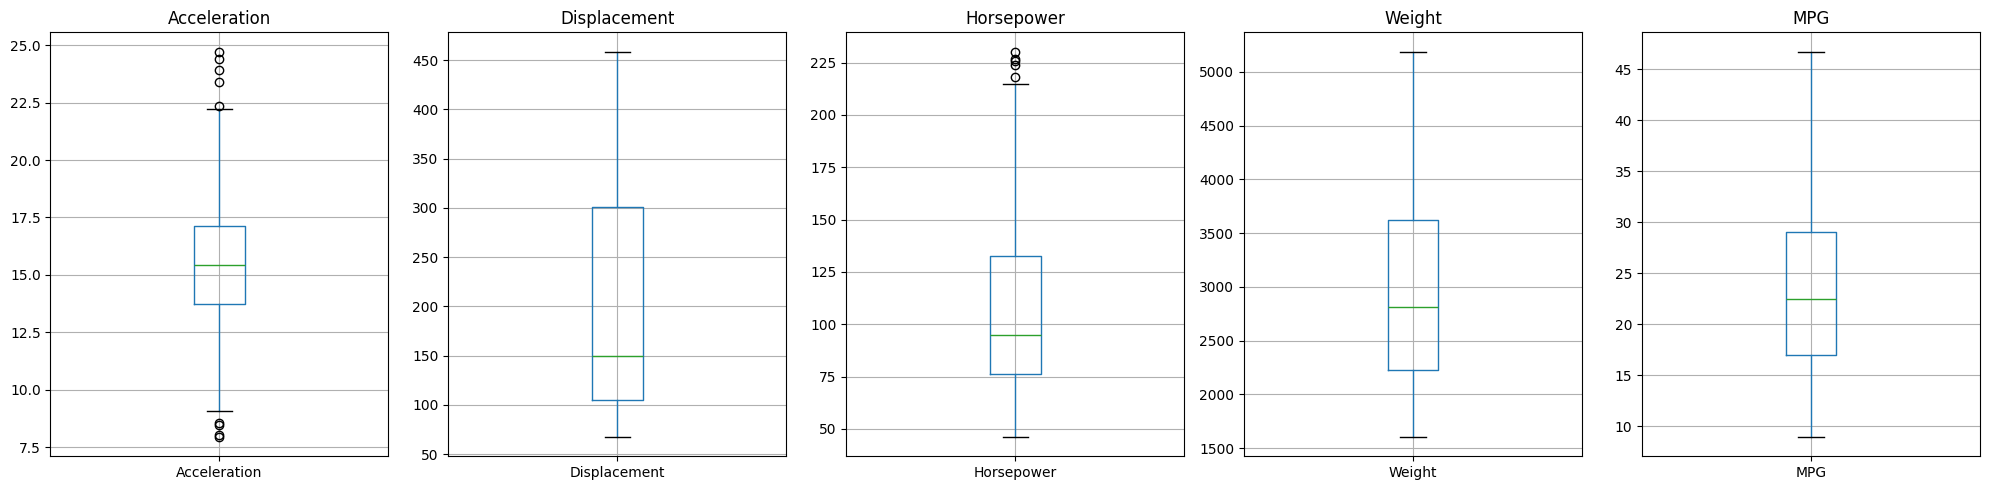

In [ ]:
df_x=pd.DataFrame(x,columns=columns)
#Kwartyle
q1 = df_x.quantile(0.25)
q3 = df_x.quantile(0.75)
median = df_x.median()
#rozstępy
rozstep = df_x.max()-df_x.min()
#rozstep miedzykwartlowy
iqr = q3 - q1
#odchylenie ćwiartkowe
odchylenie_cw=iqr/2
#typowy obszar zmiennosci
typ_min = median - odchylenie_cw
typ_max = median + odchylenie_cw
statystyki_rozproszenia = pd.DataFrame({
    'q1':q1,
    'q3':q3,
    'median':median,
    'rozstep':rozstep,
    'iqr':iqr,
    'odchylenie_cw':odchylenie_cw,
    'typ_min, od:':typ_min,
    'typ_max, do:':typ_max
})
print(statystyki_rozproszenia)
#wykres
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(columns):
    df_x.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [ ]:
  df_x = pd.DataFrame(x, columns=columns)
  n = len(df_x) #liczba wszystkich wierszy
  #odchylenie przeciętne
  odch_przecietne = (df_x - df_x.mean()).abs().mean()
  #wariancja
  wariancja = df_x.var(ddof=0)
  #odchylenie standardowe
  odch_standardowe = df_x.std(ddof=0)
  #typowy obszar zmiennosci
  klas_obszar_min = df_x.mean() - odch_standardowe
  klas_obszar_max = df_x.mean() + odch_standardowe
  #wspolczynniki zmiennosci
  v_klasyczny = (odch_standardowe / df_x.mean())
  #wspolczynnik pozycyjny
  v_pozycyjny = odchylenie_cw / df_x.mean()
  miary_rozrzutu = pd.DataFrame({
      'odch_przecietne': odch_przecietne,
      'wariancja': wariancja,
      'odch_standardowe': odch_standardowe,
      'klas_obszar_min': klas_obszar_min,
      'klas_obszar_max': klas_obszar_max,
      'v_klasyczny': v_klasyczny,
      'v_pozycyjny': v_pozycyjny,
  })
  print(miary_rozrzutu)

              odch_przecietne      wariancja  odch_standardowe  \
Acceleration         2.166813       7.771426          2.787728   
Displacement        92.235261   10984.116582        104.805136   
Horsepower          31.121504    1499.465299         38.722930   
Weight             720.928296  717838.300133        847.253386   
MPG                  6.602993      61.985417          7.873082   

              klas_obszar_min  klas_obszar_max  v_klasyczny  v_pozycyjny  
Acceleration        12.719891        18.295346     0.179765     0.110104  
Displacement        89.949560       299.559833     0.538139     0.502948  
Horsepower          67.054951       144.500810     0.366078     0.266059  
Weight            2132.494220      3827.000992     0.284337     0.233941  
MPG                 15.444713        31.190876     0.337643     0.260133  


**Krok 3: Weryfikacja rozkładów zmiennych numerycznych**

*Opis kroku: Analiza kształtu dystrybucji poprzez histogramy , obliczenie współczynników asymetrii i kurtozy oraz ocena normalności rozkładu (wykresy probplot).*

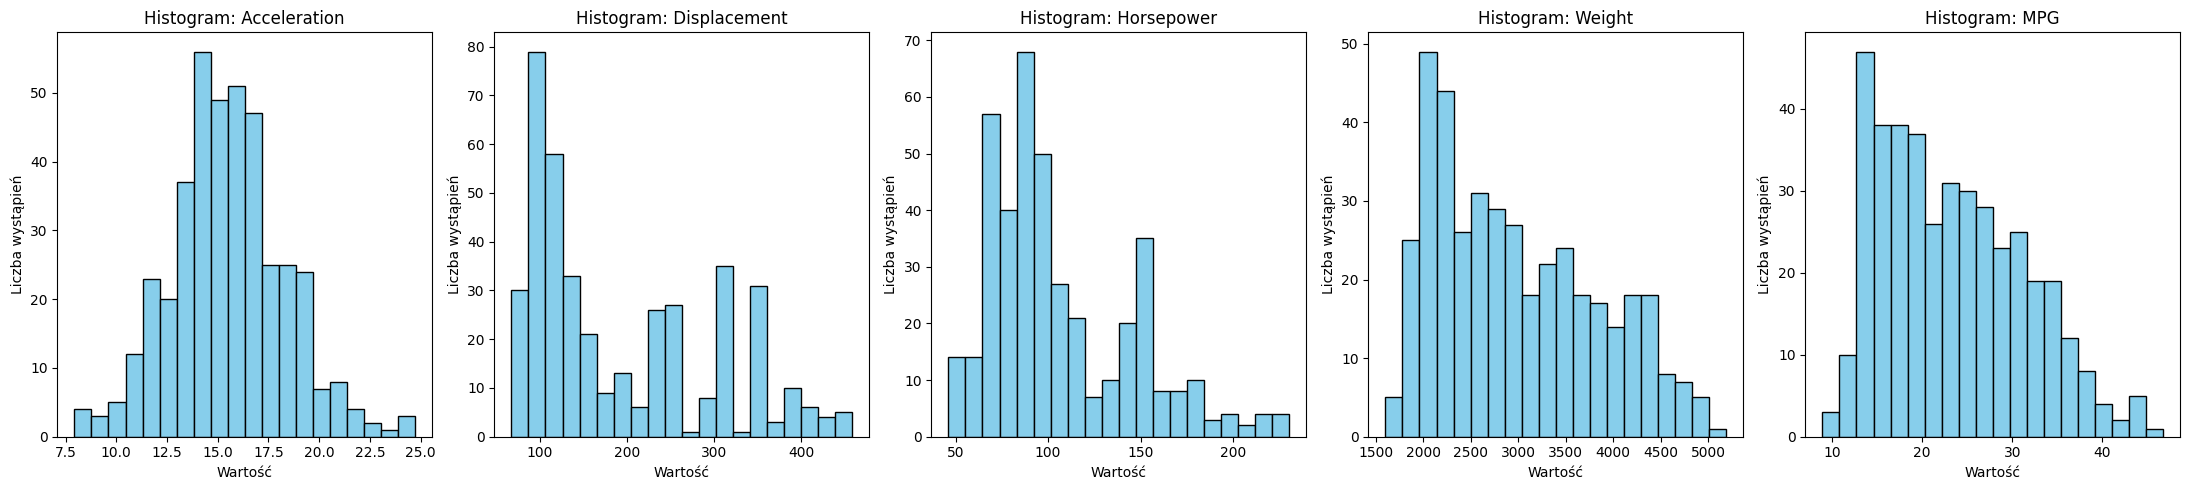

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, col in enumerate(columns):
  axes[i].hist(df_x[col],bins=20,color='skyblue',edgecolor='black')
  axes[i].set_title(f'Histogram: {col}')
  axes[i].set_xlabel('Wartość')
  axes[i].set_ylabel('Liczba wystąpień')

plt.tight_layout()
plt.show()

In [ ]:
skewness =df_x.skew()
kurt = df_x.kurtosis()

shape_measures = pd.DataFrame({
    'skośność':skewness,
    'kurtoza':kurt
})
display(shape_measures.round(3))

,skośność,kurtoza
Acceleration,0.229,0.377
Displacement,0.694,-0.813
Horsepower,0.977,0.397
Weight,0.507,-0.817
MPG,0.474,-0.517


**Krok 4: Analiza wielowymiarowa i badanie korelacji**

*Opis kroku: Wizualizacja współzależności między zmiennymi po standaryzacji (wykresy współrzędnych równoległych) oraz badanie siły powiązań za pomocą macierzy korelacji liniowej i wykresów rozrzutu.*

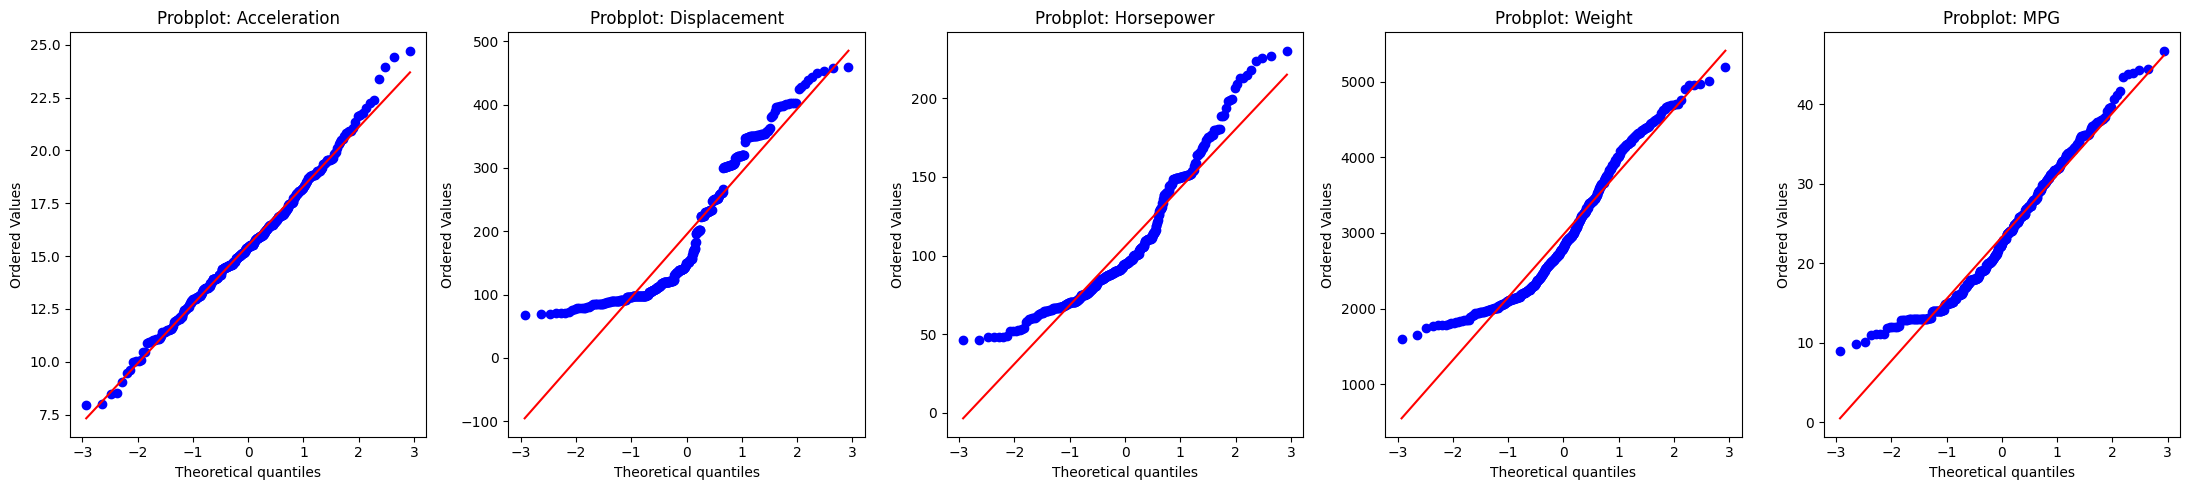

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, col in enumerate(columns):
    stats.probplot(df_x[col], dist="norm", plot=axes[i])

    axes[i].set_title(f'Probplot: {col}')

plt.tight_layout()
plt.show()

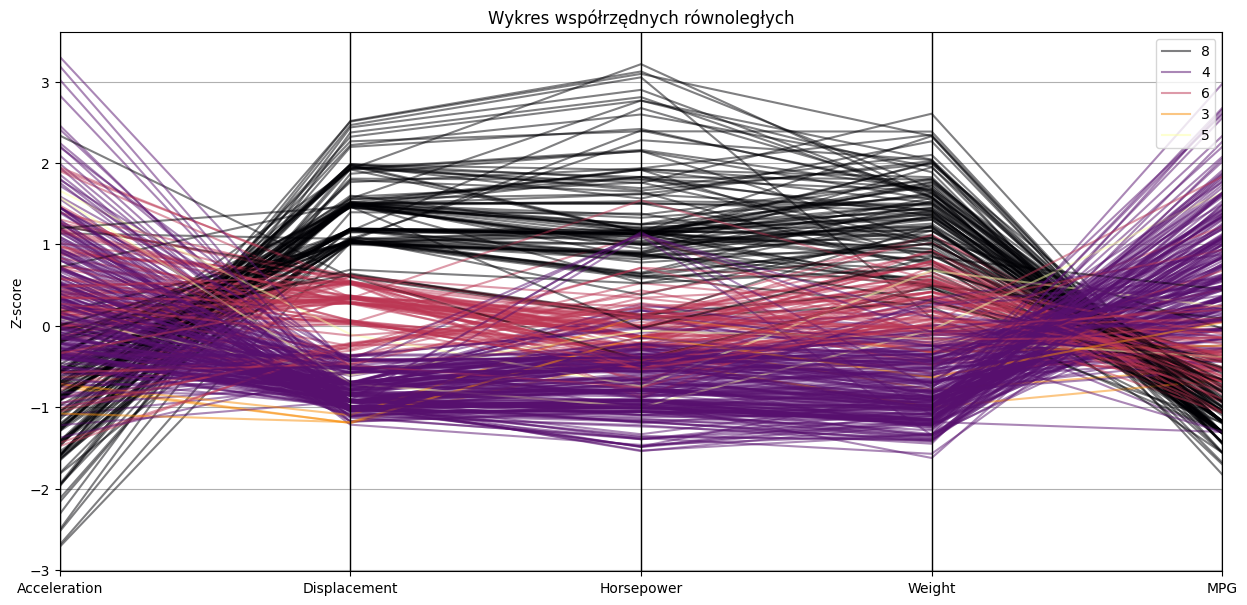

In [ ]:
from pandas.plotting import parallel_coordinates
from scipy.stats import zscore

df_to_standardize = pd.DataFrame(x, columns=columns)

#Standaryzacja
df_standardized = df_to_standardize.apply(zscore)

df_standardized['Cylinders'] = data['Cylinders'].values

#Wykres Parallel Coordinates
plt.figure(figsize=(15, 7))
parallel_coordinates(df_standardized, 'Cylinders', colormap='inferno', alpha=0.5)
plt.title('Wykres współrzędnych równoległych')
plt.ylabel('Z-score')
plt.grid(True)
plt.show()

In [ ]:
korelacja = df_x.corr()
display(korelacja.round(2))

,Acceleration,Displacement,Horsepower,Weight,MPG
Acceleration,1.00,-0.56,-0.67,-0.43,0.42
Displacement,-0.56,1.00,0.88,0.93,-0.79
Horsepower,-0.67,0.88,1.00,0.85,-0.75
Weight,-0.43,0.93,0.85,1.00,-0.82
MPG,0.42,-0.79,-0.75,-0.82,1.00


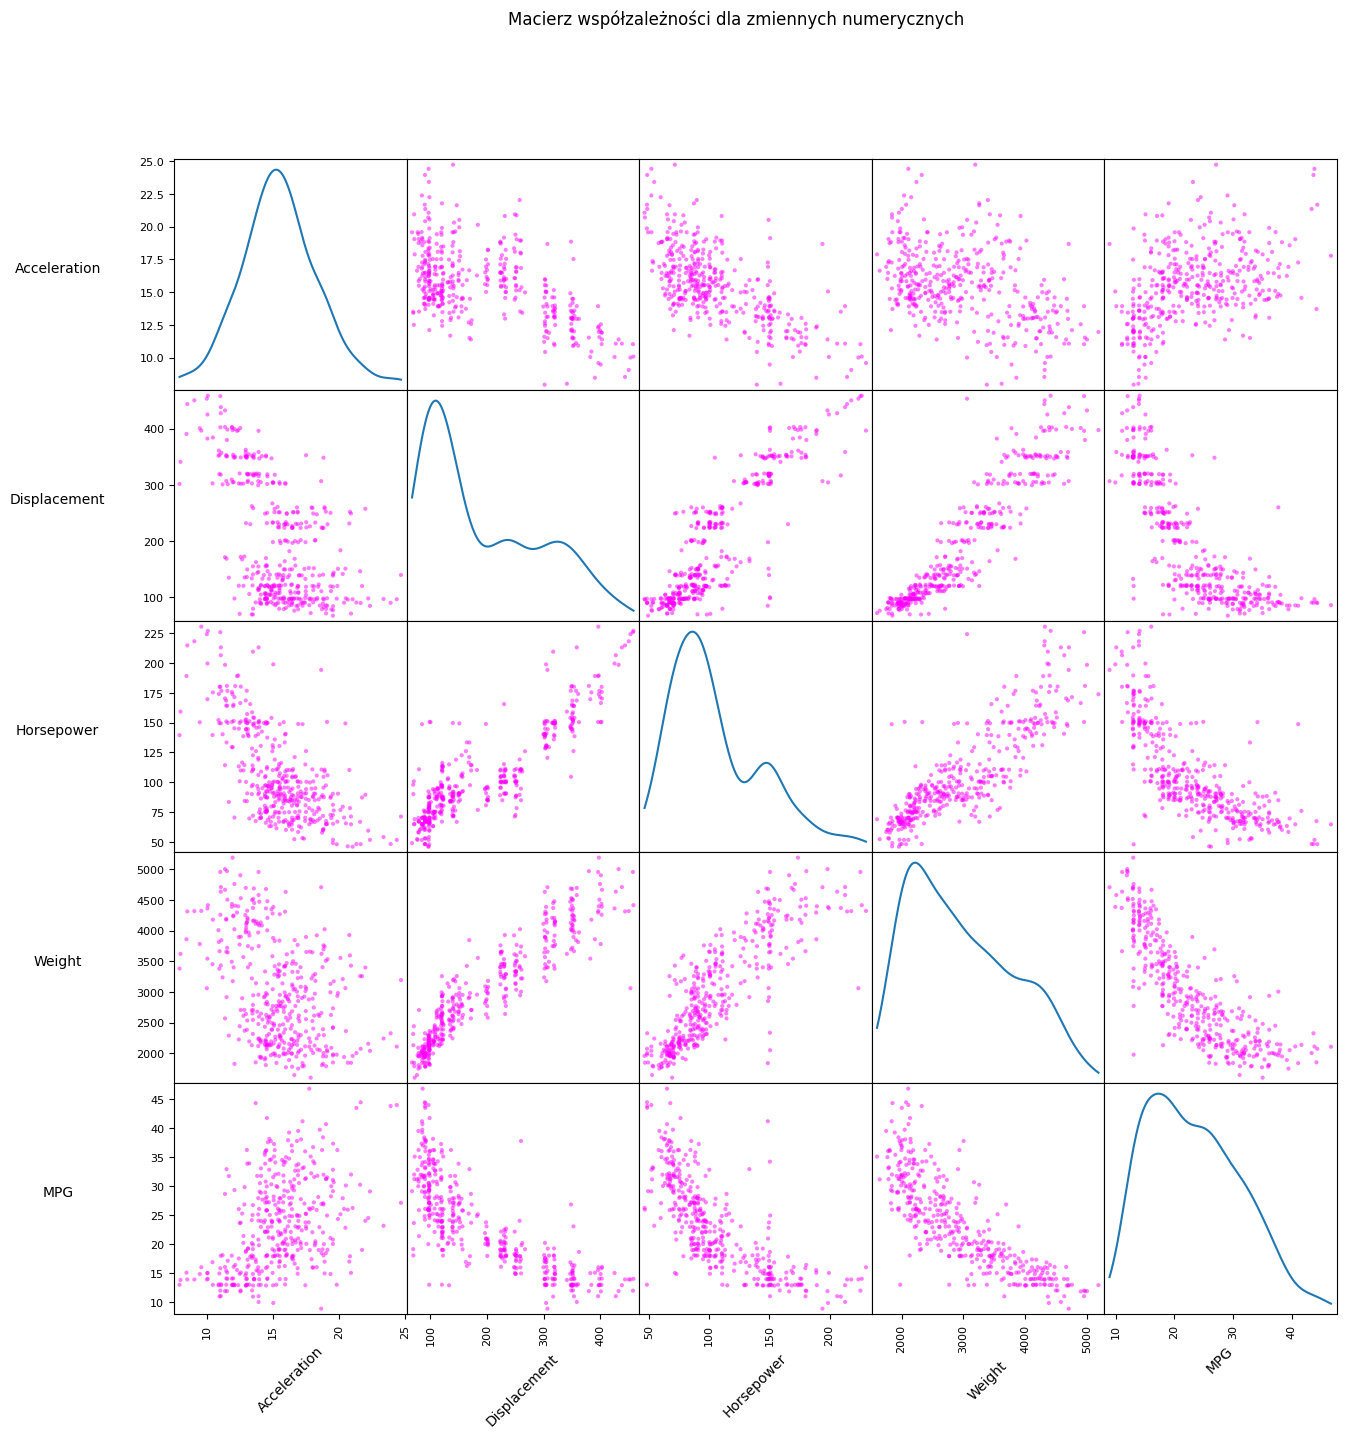

In [ ]:
from pandas.plotting import scatter_matrix
sm = scatter_matrix(df_x, alpha=0.5, figsize=(15, 15), diagonal='kde', color='magenta')

[s.xaxis.label.set_rotation(45) for s in sm.reshape(-1)]
[s.yaxis.label.set_rotation(0) for s in sm.reshape(-1)]
[s.get_yaxis().set_label_coords(-0.5, 0.5) for s in sm.reshape(-1)]

plt.suptitle('Macierz współzależności dla zmiennych numerycznych')
plt.show()

**Krok 5: Inżynieria cech (Feature Engineering) – Profilowanie zużycia paliwa**

*Opis kroku: Transformacja zmiennej MPG (Mile Per Gallon) na europejski standard zużycia paliwa w litrach na 100 km i analiza jej zależności od parametrów technicznych pojazdu (np. wagi, mocy, przyspieszenia).*

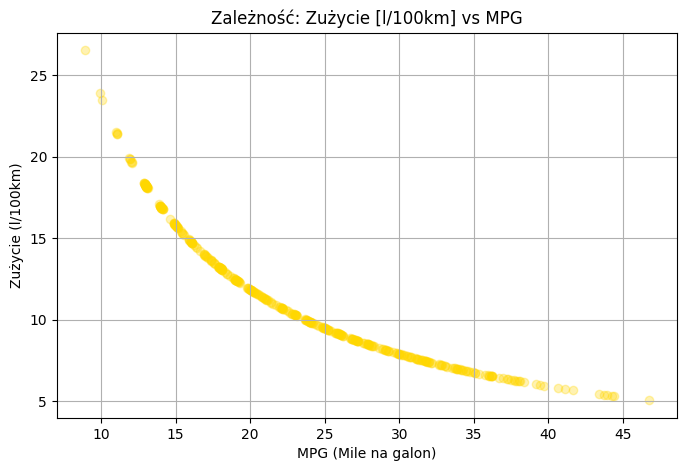

In [ ]:
df_x['Zuzycie'] = (3.79 / (df_x['MPG'] * 1.6)) * 100

plt.figure(figsize=(8, 5))
plt.scatter(df_x['MPG'], df_x['Zuzycie'], color='gold', alpha=0.3)
plt.title('Zależność: Zużycie [l/100km] vs MPG')
plt.xlabel('MPG (Mile na galon)')
plt.ylabel('Zużycie (l/100km)')
plt.grid(True)
plt.show()

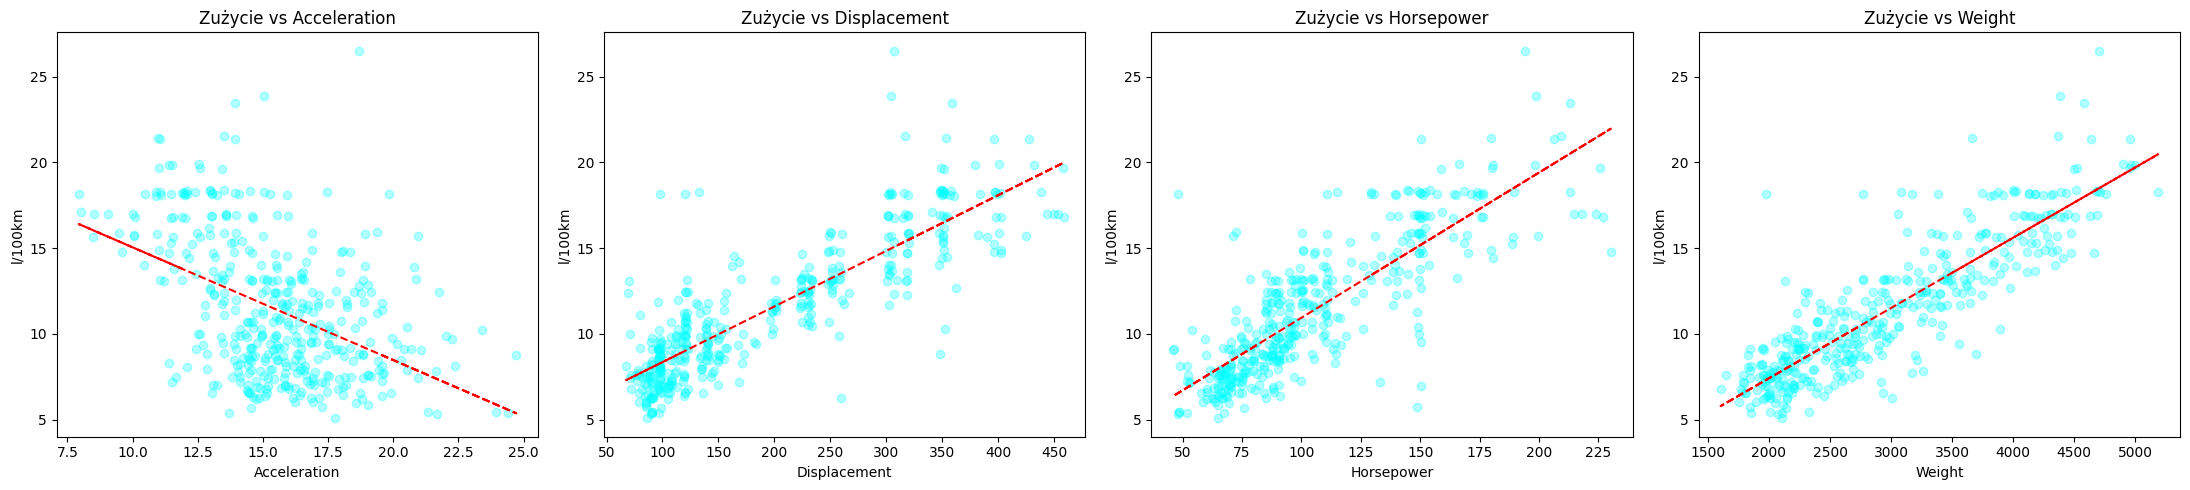

In [ ]:
features = ['Acceleration', 'Displacement', 'Horsepower', 'Weight']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, col in enumerate(features):
    axes[i].scatter(df_x[col], df_x['Zuzycie'], alpha=0.3, color='cyan')
    axes[i].set_title(f'Zużycie vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('l/100km')

    # linia trendu
    m, b = np.polyfit(df_x[col], df_x['Zuzycie'], 1)
    axes[i].plot(df_x[col], m*df_x[col] + b, color='red', linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
srednie_dane = df_x.groupby(data['Cylinders'])['Zuzycie'].mean().reset_index()
srednie_dane.columns = ['Liczba cylindrów', 'Średnie zużycie (l/100km)']
print(srednie_dane.to_string(index=False))

 Liczba cylindrów  Średnie zużycie (l/100km)
                3                  11.639112
                4                   8.529284
                5                   9.216919
                6                  12.196995
                8                  16.423261


# D. Skrócone wnioski końcowe

* **Asymetria rynku motoryzacyjnego:** Analizowany zbiór jest niejednorodny. Ze względu na silną prawostronną asymetrię dla parametrów takich jak waga, pojemność silnika i moc widoczna jest jednoznaczna przewaga pojazdów słabszych i o mniejszej masie. Auta elitarne o niezwykle potężnych parametrach stanowią na rynku zdecydowaną mniejszość.

* **Przyspieszenie jako cecha standardowa:** Czas do osiągnięcia odpowiedniej prędkości to najmniej zróżnicowana i najbardziej ustandaryzowana cecha badanych samochodów (rozkład najbardziej przypominał rozkład normalny Gaussa).

* **Silne powiązania konstrukcyjne:** Badania udowodniły bezdyskusyjne występowanie potężnych dodatnich współzależności liniowych pomiędzy masą auta a jego mocą oraz pojemnością silnika. Ingerencja inżynierska i zmiany w jednym z tych parametrów bezpośrednio pociągają za sobą zmianę w pozostałych.
